<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_1_Handling_Missing_Data_in_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# Assignment 1: Handling Missing Data in Time Series Forecasting
# Loading and Exploring the Data
# Uploading the Dataset
# Uploading file in Google Colab
from google.colab import files
uploaded = files.upload()

Saving daily-minimum-temperatures-in-me.csv to daily-minimum-temperatures-in-me (2).csv


In [31]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

In [44]:
# Loading the Dataset
import pandas as pd

# Reading the file manually and clean rows
clean_data = []

with open('daily-minimum-temperatures-in-me.csv', 'r') as file:
    for line in file:
        if line.count(',') == 1:
            clean_data.append(line.strip())

# Splitting rows
df = pd.DataFrame([row.split(',') for row in clean_data])

# 🔎 Checking what columns look like BEFORE renaming
print("Columns before renaming:", df.columns)

# Forcing correct column names using position
df = df.rename(columns={0: 'Date', 1: 'Temp'})

# Removing quotes
df['Date'] = df['Date'].str.replace('"', '', regex=False)
df['Temp'] = df['Temp'].str.replace('"', '', regex=False)
df['Temp'] = df['Temp'].str.replace('?', '', regex=False)

# Converting safely
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

# Dropping the invalid rows
df.dropna(inplace=True)

# Setting index
df.set_index('Date', inplace=True)

df.head()

Columns before renaming: RangeIndex(start=0, stop=2, step=1)


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [45]:
# Check Missing Values
# Count missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Total missing
print("\nTotal Missing Values:", df.isnull().sum().sum())

"""Answer: -

The original dataset normaly contains 0 missing values"""

Missing Values:
 Temp    0
dtype: int64

Total Missing Values: 0


'Answer: -\n\nThe original dataset normaly contains 0 missing values'

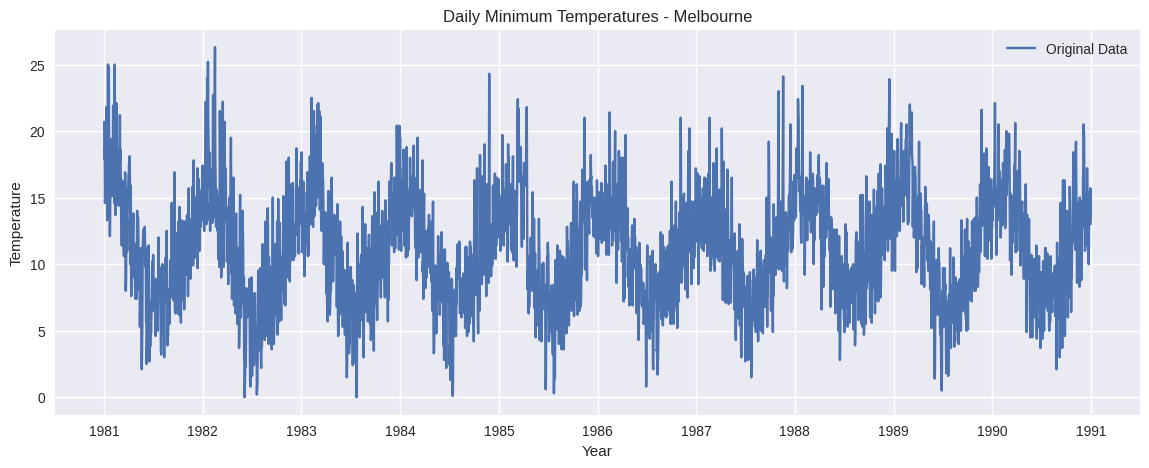

In [46]:
# Plotting Original Data
plt.figure(figsize=(14,5))
plt.plot(df, label='Original Data')
plt.title('Daily Minimum Temperatures - Melbourne')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.legend()
plt.show()

The Observations:
The dataset shows: -
•	Clear seasonality (on yearly pattern)
•	Slight long-term variation
•	Repeating summer/winter cycles

In [48]:
# Introducing Missing Values
# Creating Artificial Missing Values
# Creating a copy
df_missing = df.copy()

# Introducing 5% missing values randomly
np.random.seed(42)
missing_indices = np.random.choice(df_missing.index,
                                   size=int(len(df_missing)*0.05),
                                   replace=False)

df_missing.loc[missing_indices] = np.nan

# Checking new missing count
print("New Missing Values:", df_missing.isnull().sum())

New Missing Values: Temp    182
dtype: int64


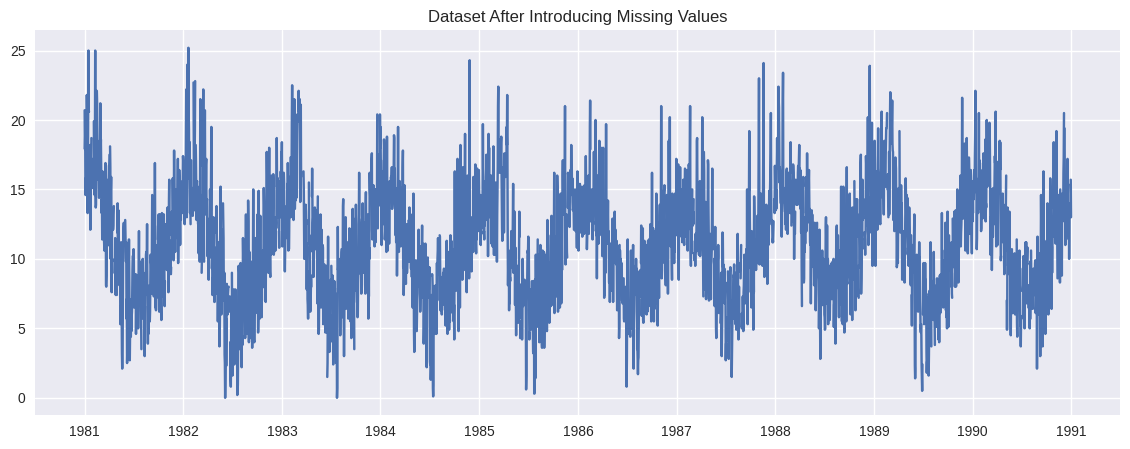

In [49]:
# Visualizing the Missing Data
plt.figure(figsize=(14,5))
plt.plot(df_missing, label='With Missing Values')
plt.title('Dataset After Introducing Missing Values')
plt.show()

In [51]:
# Applying Imputation Methods
# Mean Imputation
df_mean = df_missing.copy()

# Replacing missing with column mean
df_mean['Temp'] = df_mean['Temp'].fillna(df_mean['Temp'].mean())

print("Remaining Missing (Mean):", df_mean.isnull().sum())

Remaining Missing (Mean): Temp    0
dtype: int64


In [52]:
# Forward Fill
df_ffill = df_missing.copy()

# Forward fill
df_ffill['Temp'] = df_ffill['Temp'].fillna(method='ffill')

print("Remaining Missing (Forward Fill):", df_ffill.isnull().sum())

Remaining Missing (Forward Fill): Temp    0
dtype: int64


/tmp/ipython-input-378/3086621079.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill['Temp'] = df_ffill['Temp'].fillna(method='ffill')


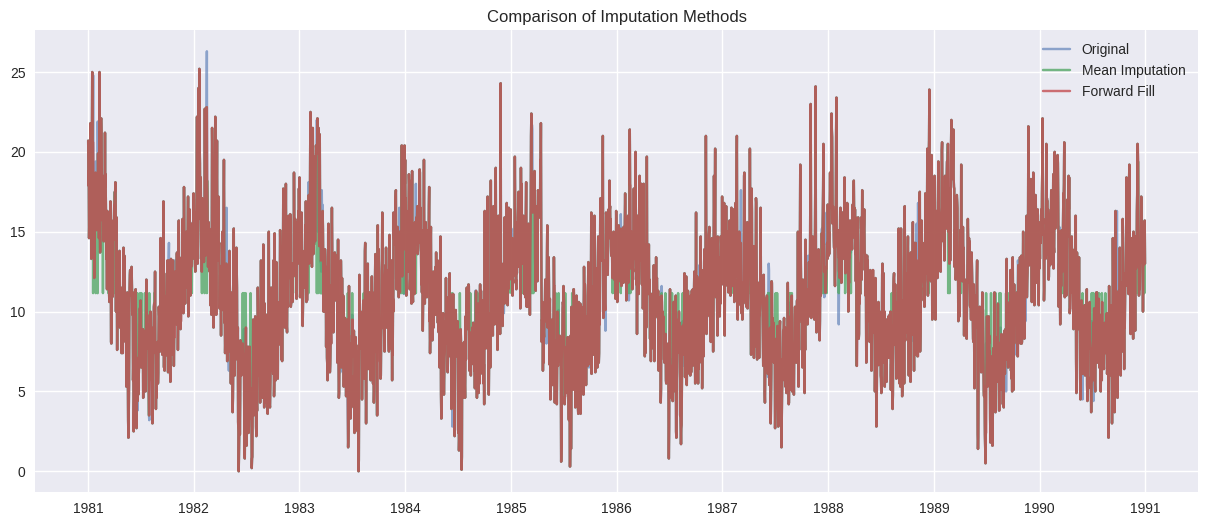

In [53]:
# Comparing Imputation Methods
# Plot Comparison
plt.figure(figsize=(15,6))

plt.plot(df, label='Original', alpha=0.6)
plt.plot(df_mean, label='Mean Imputation', alpha=0.8)
plt.plot(df_ffill, label='Forward Fill', alpha=0.8)

plt.title('Comparison of Imputation Methods')
plt.legend()
plt.show()